## Loading the dataset

In [ ]:

import os
import pandas as pd

try:
    base = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base = os.getcwd()

path = os.path.join(base, 'KoTaP_Dataset (1).csv')

df = pd.read_csv(path, encoding='cp949')

print("Loaded with cp949 encoding")
print(df.head())


Loaded with cp949 encoding
   name  stock  year  KOSPI  fnd_year  fiscal  ind  big4    forn     own  ...  \
0  동화약품     20  2013      1      1897      12   21     1  0.0613  0.3114  ...   
1  동화약품     20  2014      1      1897      12   21     1  0.0502  0.3151  ...   
2  동화약품     20  2015      1      1897      12   21     1  0.0749  0.3235  ...   
3  동화약품     20  2016      1      1897      12   21     1  0.0746  0.3229  ...   
4  동화약품     20  2017      1      1897      12   21     1  0.1186  0.3240  ...   

      GETR5     CETR5      TSTA      TSDA    A_GETR    A_CETR   A_GETR3  \
0  0.294414  0.266121 -0.071863 -0.088363 -0.236479  0.748503  0.058765   
1  0.233461  0.418783 -0.001226 -0.014614 -0.150710  0.748503  0.500993   
2  0.231593  0.528209  0.072994  0.056283 -0.171420 -0.024525 -0.195255   
3  0.306044  0.325968  0.106756  0.107570  0.026917 -0.194237 -0.174602   
4  0.250474  0.216419 -0.061506  0.008744  0.042469 -0.157749 -0.014648   

    A_CETR3   A_GETR5   A_CETR5  
0

## Label and Split

In [2]:
df['label_cetr']=(df['CETR']<=df['CETR'].quantile(0.25)).astype(int)
df['label_getr']=(df['GETR']<=df['GETR'].quantile(0.25)).astype(int)
train=df[df['year']<=2019]
test=df[df['year']>=2020]
num=['SIZE','LEV','ROA','CFO','MB','TQ']
cat=['ind']

## RQ1 Feature Selection

In [3]:
from sklearn.feature_selection import VarianceThreshold,SelectKBest,mutual_info_classif
sel=VarianceThreshold(1e-4).fit(train[num])
num_rq1=[c for c,k in zip(num, sel.get_support()) if k]
corr=train[num_rq1].corr().abs()
import numpy as np
upper=corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop=[col for col in upper.columns if any(upper[col]>0.9)]
num_rq1=[c for c in num_rq1 if c not in drop]
sel2=SelectKBest(mutual_info_classif,k='all').fit(train[num_rq1],train['label_cetr'])
num_rq1=[c for c,k in zip(num_rq1, sel2.get_support()) if k]
print('RQ1 Features:', num_rq1)

RQ1 Features: ['SIZE', 'LEV', 'ROA', 'CFO', 'MB']


## RQ1 Models

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

X_train=train[num_rq1+cat]
y_train=train['label_cetr']
X_test=test[num_rq1+cat]
y_test=test['label_cetr']

pre=ColumnTransformer([
 ('num',Pipeline([('imp',SimpleImputer()),('sc',StandardScaler())]),num_rq1),
 ('cat',OneHotEncoder(handle_unknown='ignore'),cat)
])

log_rq1=Pipeline([('prep',pre),('clf',LogisticRegression(max_iter=500))])
knn_rq1=Pipeline([('prep',pre),('clf',KNeighborsClassifier())])
log_rq1.fit(X_train,y_train)
knn_rq1.fit(X_train,y_train)

for name,model in [('Logistic',log_rq1),('KNN',knn_rq1)]:
    pred=model.predict(X_test)
    print(name,'Accuracy:',accuracy_score(y_test,pred))
    print(confusion_matrix(y_test,pred))
    print(classification_report(y_test,pred))

Logistic Accuracy: 0.7125899980540962
[[3632   26]
 [1451   30]]
              precision    recall  f1-score   support

           0       0.71      0.99      0.83      3658
           1       0.54      0.02      0.04      1481

    accuracy                           0.71      5139
   macro avg       0.63      0.51      0.44      5139
weighted avg       0.66      0.71      0.60      5139

KNN Accuracy: 0.7102549134072776
[[3382  276]
 [1213  268]]
              precision    recall  f1-score   support

           0       0.74      0.92      0.82      3658
           1       0.49      0.18      0.26      1481

    accuracy                           0.71      5139
   macro avg       0.61      0.55      0.54      5139
weighted avg       0.67      0.71      0.66      5139



## RQ2 Governance Models

In [5]:
gov=['big4','forn','own','KOSPI','SIZE']
X_train2=train[gov+cat]
y_train2=train['label_cetr']
X_test2=test[gov+cat]
y_test2=test['label_cetr']

pre2=ColumnTransformer([
 ('num',Pipeline([('imp',SimpleImputer()),('sc',StandardScaler())]),gov),
 ('cat',OneHotEncoder(handle_unknown='ignore'),cat)
])

log_rq2=Pipeline([('prep',pre2),('clf',LogisticRegression(max_iter=500))])
knn_rq2=Pipeline([('prep',pre2),('clf',KNeighborsClassifier())])
log_rq2.fit(X_train2,y_train2)
knn_rq2.fit(X_train2,y_train2)

for name,model in [('Logistic',log_rq2),('KNN',knn_rq2)]:
    pred=model.predict(X_test2)
    print(name,'Accuracy:',accuracy_score(y_test2,pred))
    print(confusion_matrix(y_test2,pred))
    print(classification_report(y_test2,pred))

Logistic Accuracy: 0.7135629499902705
[[3651    7]
 [1465   16]]
              precision    recall  f1-score   support

           0       0.71      1.00      0.83      3658
           1       0.70      0.01      0.02      1481

    accuracy                           0.71      5139
   macro avg       0.70      0.50      0.43      5139
weighted avg       0.71      0.71      0.60      5139

KNN Accuracy: 0.696244405526367
[[3304  354]
 [1207  274]]
              precision    recall  f1-score   support

           0       0.73      0.90      0.81      3658
           1       0.44      0.19      0.26      1481

    accuracy                           0.70      5139
   macro avg       0.58      0.54      0.53      5139
weighted avg       0.65      0.70      0.65      5139



## RQ3 KMeans Clustering

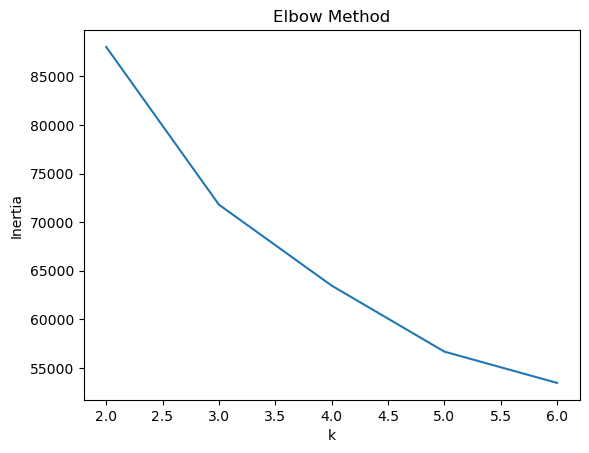

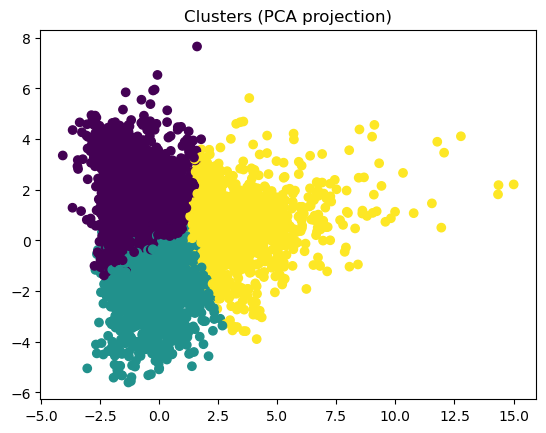

Cluster centers (scaled):
[[ 0.51349682  0.40226901  0.17429861  0.18878769  0.5312119   0.59211234
  -0.53798583 -0.41829436]
 [-0.38931545 -0.24636492  0.36225563  0.35255288 -0.23830637 -0.42069394
   0.44270603  0.40976507]
 [-0.27445508 -0.4488975  -2.06575985 -2.07862048 -0.940017   -0.42908788
   0.14860151 -0.14600547]]


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

clust=['CETR','GETR','TSTA','TSDA','SIZE','LEV','ROA','CFO']
X=df[clust].dropna()
sc=StandardScaler().fit_transform(X)

inertia=[]
for k in range(2,7):
    km=KMeans(n_clusters=k,random_state=0)
    km.fit(sc)
    inertia.append(km.inertia_)

plt.plot(range(2,7),inertia)
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.show()

km=KMeans(n_clusters=3,random_state=0).fit(sc)
p=X.index
pca=PCA(n_components=2).fit_transform(sc)
plt.scatter(pca[:,0],pca[:,1],c=km.labels_)
plt.title('Clusters (PCA projection)')
plt.show()
print('Cluster centers (scaled):')
print(km.cluster_centers_)